
### STAGE 5: Feature Engineering & Selection


#### 5.1 Importing Required Libraries

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')


All libraries imported successfully.


#### 5.2 Load the Dataset

In [30]:
df = pd.read_csv('Crop_recommendation.csv')

print(f'Shape         : {df.shape}')
print(f'Unique crops  : {df["label"].nunique()}')
print(f'Samples/crop  : {df["label"].value_counts().unique()} (perfectly balanced)')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates    : {df.duplicated().sum()}')
df.describe().round(2)


Shape         : (2200, 8)
Unique crops  : 22
Samples/crop  : [100] (perfectly balanced)
Missing values: 0
Duplicates    : 0


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


#### 5.3 Feature Importance Analysis

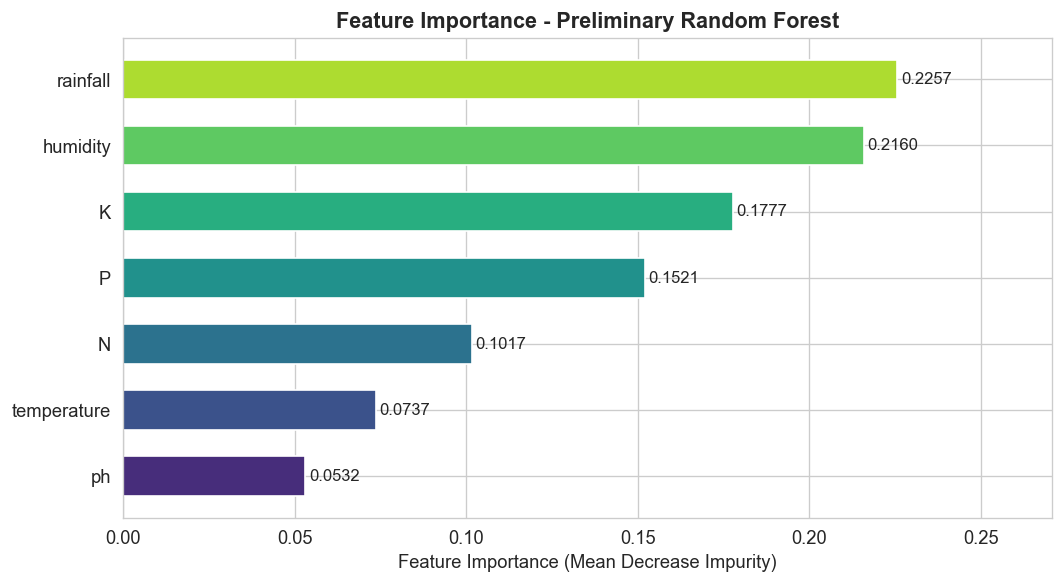

Ranking (highest to lowest):
  rainfall       : 0.2257
  humidity       : 0.2160
  K              : 0.1777
  P              : 0.1521
  N              : 0.1017
  temperature    : 0.0737
  ph             : 0.0532


In [33]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
feature_cols = FEATURES
X_all = df[feature_cols].values
y_all = df['label_enc'].values
classes = le.classes_

rf_prelim = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_prelim.fit(X_all, y_all)

importances = rf_prelim.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('viridis', len(feature_cols))
bars = ax.barh([feature_cols[i] for i in idx], importances[idx],
               color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, importances[idx]):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title('Feature Importance - Preliminary Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max()*1.2)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('Ranking (highest to lowest):')
for i in idx[::-1]:
    print(f'  {feature_cols[i]:15s}: {importances[i]:.4f}')


#### 5.4 Dimensionality Reduction

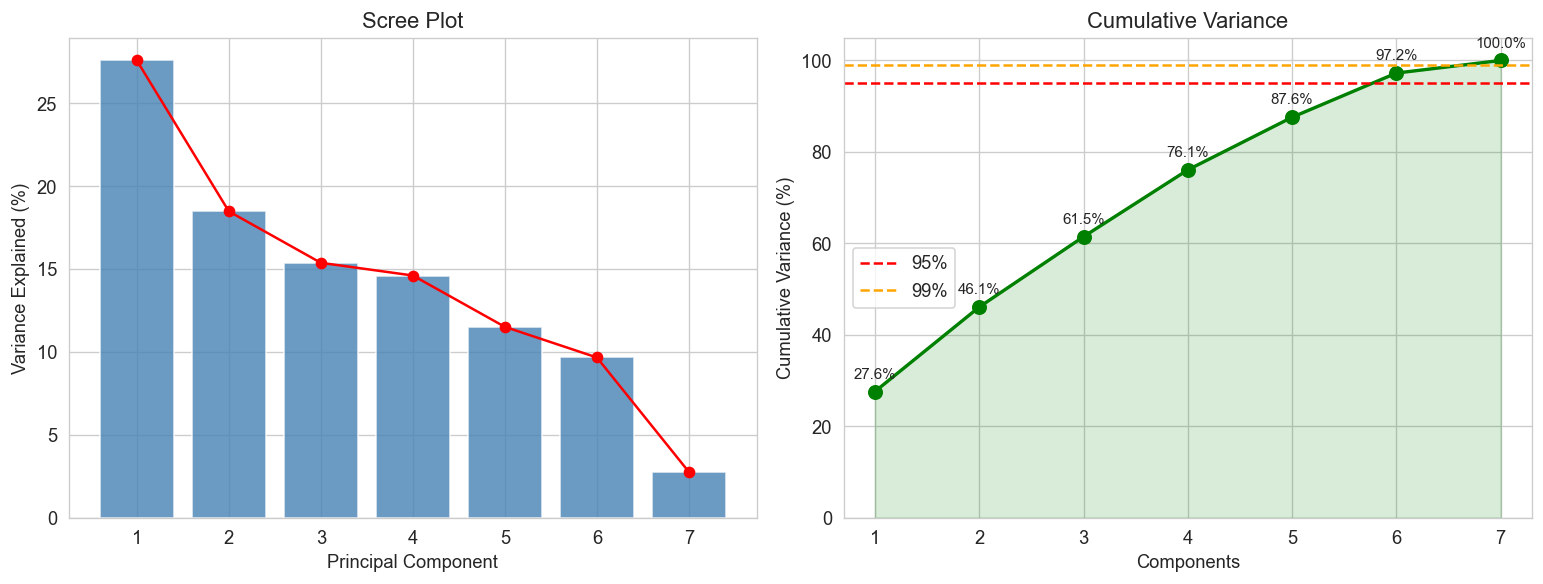

Decision: All 7 features needed for 99% variance. No dimensionality reduction applied.
Reducing features would hurt interpretability without meaningful computational gain.


In [34]:
X_scaled_pca = StandardScaler().fit_transform(X_all)
pca = PCA().fit(X_scaled_pca)
cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1,8), pca.explained_variance_ratio_*100,
            color='steelblue', edgecolor='white', alpha=0.8)
axes[0].plot(range(1,8), pca.explained_variance_ratio_*100, 'ro-', markersize=6)
axes[0].set(xlabel='Principal Component', ylabel='Variance Explained (%)',
            title='Scree Plot', xticks=range(1,8))

axes[1].plot(range(1,8), cum_var*100, 'go-', markersize=8, linewidth=2)
axes[1].axhline(95, color='red',    linestyle='--', label='95%')
axes[1].axhline(99, color='orange', linestyle='--', label='99%')
axes[1].fill_between(range(1,8), cum_var*100, alpha=0.15, color='green')
for i, v in enumerate(cum_var*100):
    axes[1].annotate(f'{v:.1f}%', (i+1, v), xytext=(0,8),
                     textcoords='offset points', ha='center', fontsize=9)
axes[1].set(xlabel='Components', ylabel='Cumulative Variance (%)',
            title='Cumulative Variance', xticks=range(1,8), ylim=(0,105))
axes[1].legend()
plt.tight_layout()
plt.savefig('pca_analysis.png', bbox_inches='tight')
plt.show()

print('Decision: All 7 features needed for 99% variance. No dimensionality reduction applied.')
print('Reducing features would hurt interpretability without meaningful computational gain.')


#### 5.9 Final Feature Selection & Data Preparation

In [35]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

X = df[FEATURES].values
y = df['label_enc'].values

# Stratified 80/20 split -- ensures all 22 crops appear in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# StandardScaler -- fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Data preparation complete.')
print(f'  Train : {X_train.shape[0]} samples')
print(f'  Test  : {X_test.shape[0]} samples')
print(f'  Crops : {len(classes)}')
print()
# Verify class balance in split
train_counts = pd.Series(y_train).value_counts()
print(f'  Samples per crop in train set: min={train_counts.min()}, max={train_counts.max()}')
print(f'  Samples per crop in test  set: ', end='')
test_counts = pd.Series(y_test).value_counts()
print(f'min={test_counts.min()}, max={test_counts.max()}')


Data preparation complete.
  Train : 1760 samples
  Test  : 440 samples
  Crops : 22

  Samples per crop in train set: min=80, max=80
  Samples per crop in test  set: min=20, max=20


## STAGE 6: Model Building & Training

Three models are evaluated: **Random Forest**, **KNN**, and **Decision Tree**.

#### 6.0 Helper Functions

In [36]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_pred_tr = model.predict(X_tr)
    train_acc = accuracy_score(y_tr, y_pred_tr)
    test_acc  = accuracy_score(y_te, y_pred)
    gap = train_acc - test_acc

    print('=' * 62)
    print(f'  {name}')
    print('=' * 62)
    print(f'  Training Accuracy : {train_acc*100:.2f}%')
    print(f'  Testing  Accuracy : {test_acc*100:.2f}%')
    status = 'Low (Good)' if gap < 0.05 else 'Moderate (Watch)' if gap < 0.10 else 'High (Overfit)'
    print(f'  Overfitting Gap   : {gap*100:.2f}%  --> {status}')
    print()
    print(classification_report(y_te, y_pred, target_names=classes))

    return {'name': name, 'train_acc': round(train_acc*100,2),
            'test_acc': round(test_acc*100,2), 'gap': round(gap*100,2),
            'y_pred': y_pred, 'model': model}


def plot_cm(y_true, y_pred, title):
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(15, 13))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set(xlabel='Predicted Label', ylabel='True Label', title=title)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.tight_layout()


print('Helper functions defined.')


Helper functions defined.


#### 6.1 Model 1 - Random Forest Classifier

In [37]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,   # Each leaf needs >= 2 samples -- prevents memorization
    min_samples_split=5,  # Each split needs >= 5 samples
    max_features='sqrt',  # Use sqrt(n_features) at each split -- standard for classification
    random_state=42,
    n_jobs=-1
)

results_rf = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test,
    name='Random Forest'
)

  Random Forest
  Training Accuracy : 100.00%
  Testing  Accuracy : 99.32%
  Overfitting Gap   : 0.68%  --> Low (Good)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon   

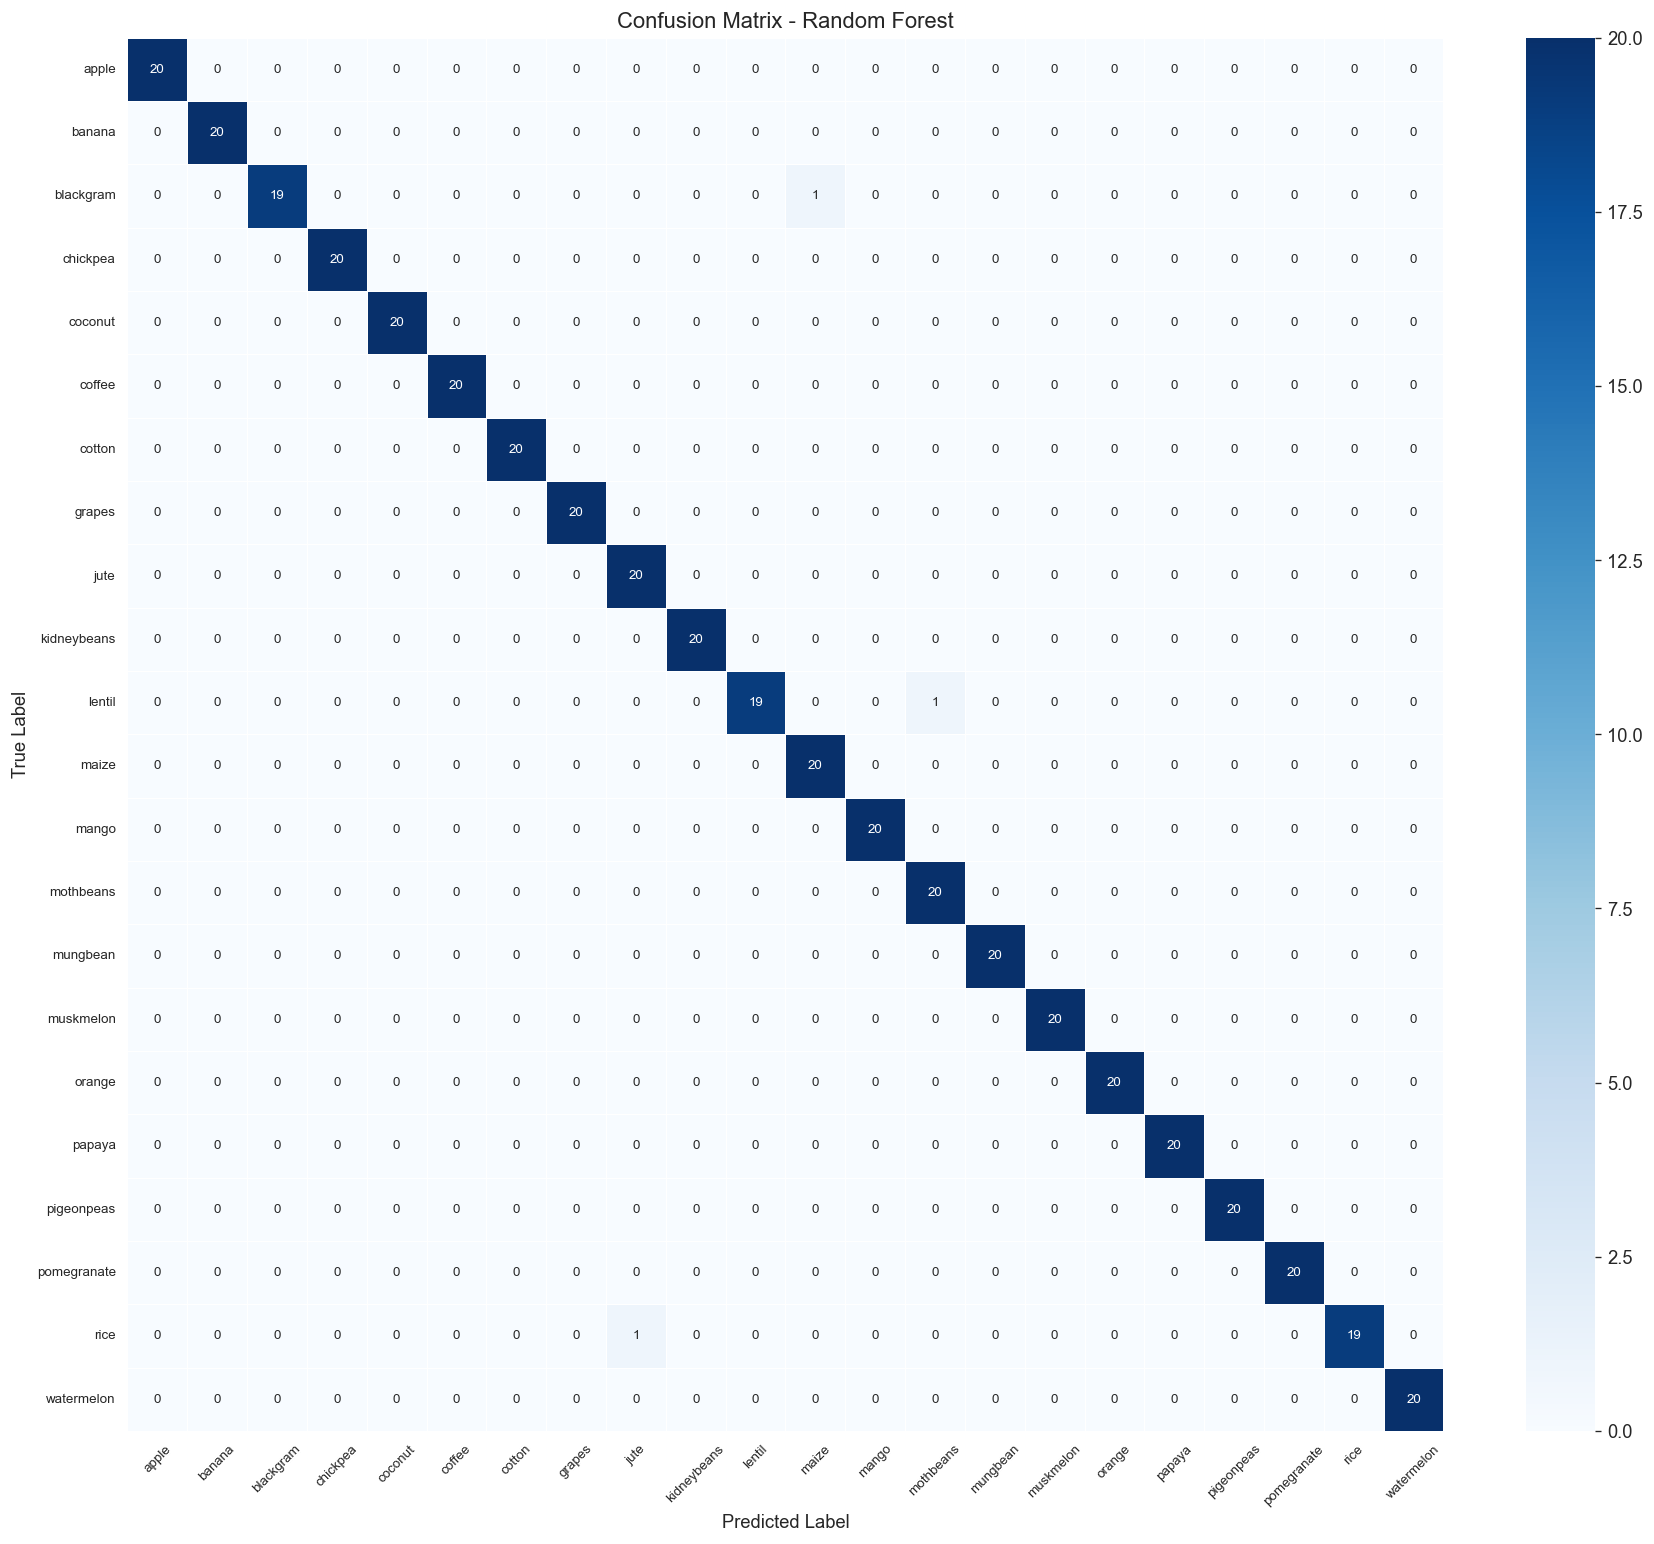

In [38]:
plot_cm(y_test, results_rf['y_pred'], 'Confusion Matrix - Random Forest')
plt.savefig('cm_random_forest.png', bbox_inches='tight')
plt.show()


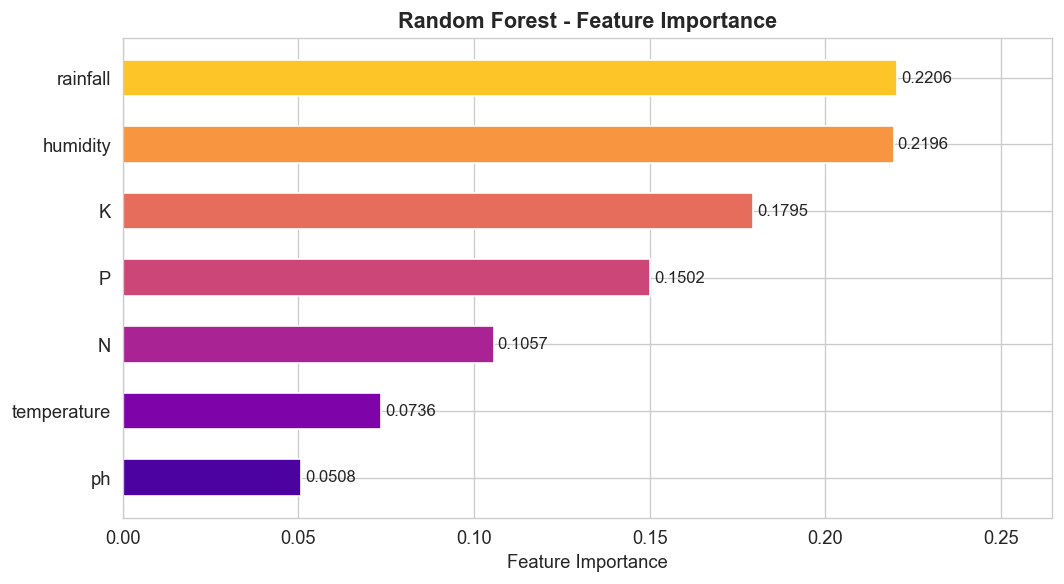

In [39]:
# Feature importance from trained model
imp    = rf_model.feature_importances_
idx_s  = np.argsort(imp)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('plasma', len(FEATURES))
bars = ax.barh([FEATURES[i] for i in idx_s], imp[idx_s],
               color=colors, edgecolor='white', height=0.55)
for bar, v in zip(bars, imp[idx_s]):
    ax.text(v+0.001, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest - Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlim(0, imp.max()*1.2)
plt.tight_layout()
plt.savefig('rf_feature_importance_trained.png', bbox_inches='tight')
plt.show()


In [40]:
cv_rf = cross_val_score(rf_model, X, y,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         scoring='accuracy', n_jobs=-1)
print('Random Forest - 5-Fold Stratified CV:')
print(f'  Fold scores : {[round(s*100,2) for s in cv_rf]}')
print(f'  Mean        : {cv_rf.mean()*100:.2f}%')
print(f'  Std Dev     : +/- {cv_rf.std()*100:.2f}%')
print()
print('Interpretation: Low std dev across folds confirms the model is')
print('  stable and not overfitting to any particular data subset.')


Random Forest - 5-Fold Stratified CV:
  Fold scores : [np.float64(99.32), np.float64(99.55), np.float64(100.0), np.float64(99.77), np.float64(99.09)]
  Mean        : 99.55%
  Std Dev     : +/- 0.32%

Interpretation: Low std dev across folds confirms the model is
  stable and not overfitting to any particular data subset.


#### 6.2 Model 2 - K-Nearest Neighbors (KNN)

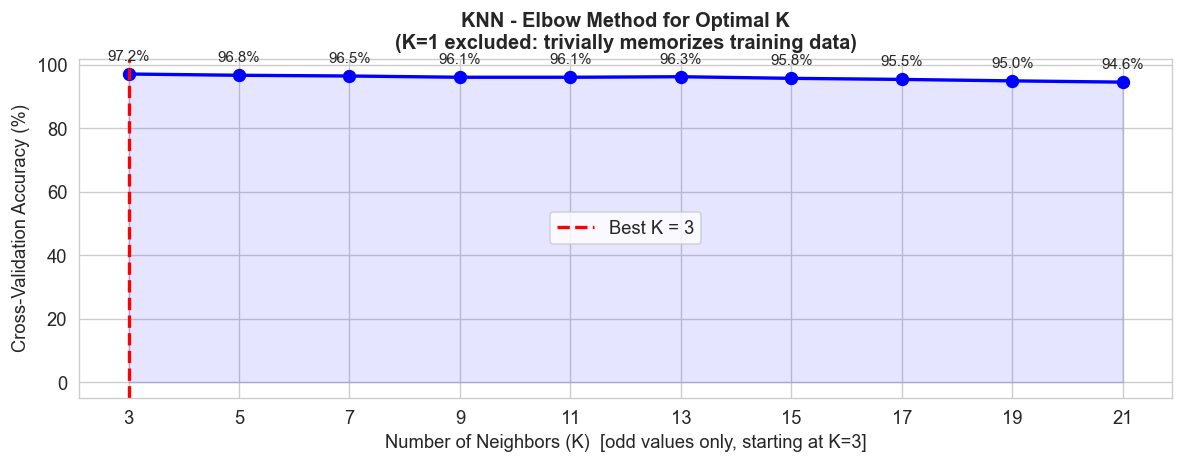

Optimal K: 3
CV Accuracy at best K: 97.16%

Note: K=1 is NOT used even if it shows highest CV accuracy.
  K=1 has 100% training accuracy by definition (memorization).
  We use K=3 which gives the best GENERALISATION performance.


In [41]:
# Find optimal K -- evaluated on VALIDATION accuracy, not training accuracy
# K=1 is excluded because it trivially memorizes training data
k_range  = range(3, 22, 2)  # Odd values only to avoid ties; start from 3
k_scores = []

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    cv_tmp  = cross_val_score(knn_tmp, X_train_sc, y_train, cv=5, scoring='accuracy')
    k_scores.append(cv_tmp.mean())

best_k = list(k_range)[int(np.argmax(k_scores))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(k_range), [s*100 for s in k_scores], 'bo-', markersize=7, linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'Best K = {best_k}')
ax.fill_between(list(k_range), [s*100 for s in k_scores], alpha=0.1, color='blue')
for k, s in zip(k_range, k_scores):
    ax.annotate(f'{s*100:.1f}%', (k, s*100), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
ax.set_xlabel('Number of Neighbors (K)  [odd values only, starting at K=3]')
ax.set_ylabel('Cross-Validation Accuracy (%)')
ax.set_title('KNN - Elbow Method for Optimal K\n'
             '(K=1 excluded: trivially memorizes training data)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('knn_elbow.png', bbox_inches='tight')
plt.show()

print(f'Optimal K: {best_k}')
print(f'CV Accuracy at best K: {max(k_scores)*100:.2f}%')
print()
print('Note: K=1 is NOT used even if it shows highest CV accuracy.')
print('  K=1 has 100% training accuracy by definition (memorization).')
print(f'  We use K={best_k} which gives the best GENERALISATION performance.')


In [42]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='distance'  # Closer neighbors have more influence
)

results_knn = evaluate_model(
    knn_model, X_train_sc, y_train, X_test_sc, y_test,
    name=f'KNN (K={best_k})'
)


  KNN (K=3)
  Training Accuracy : 100.00%
  Testing  Accuracy : 97.50%
  Overfitting Gap   : 2.50%  --> Low (Good)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.95      0.90      0.92        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.94      0.85      0.89        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       

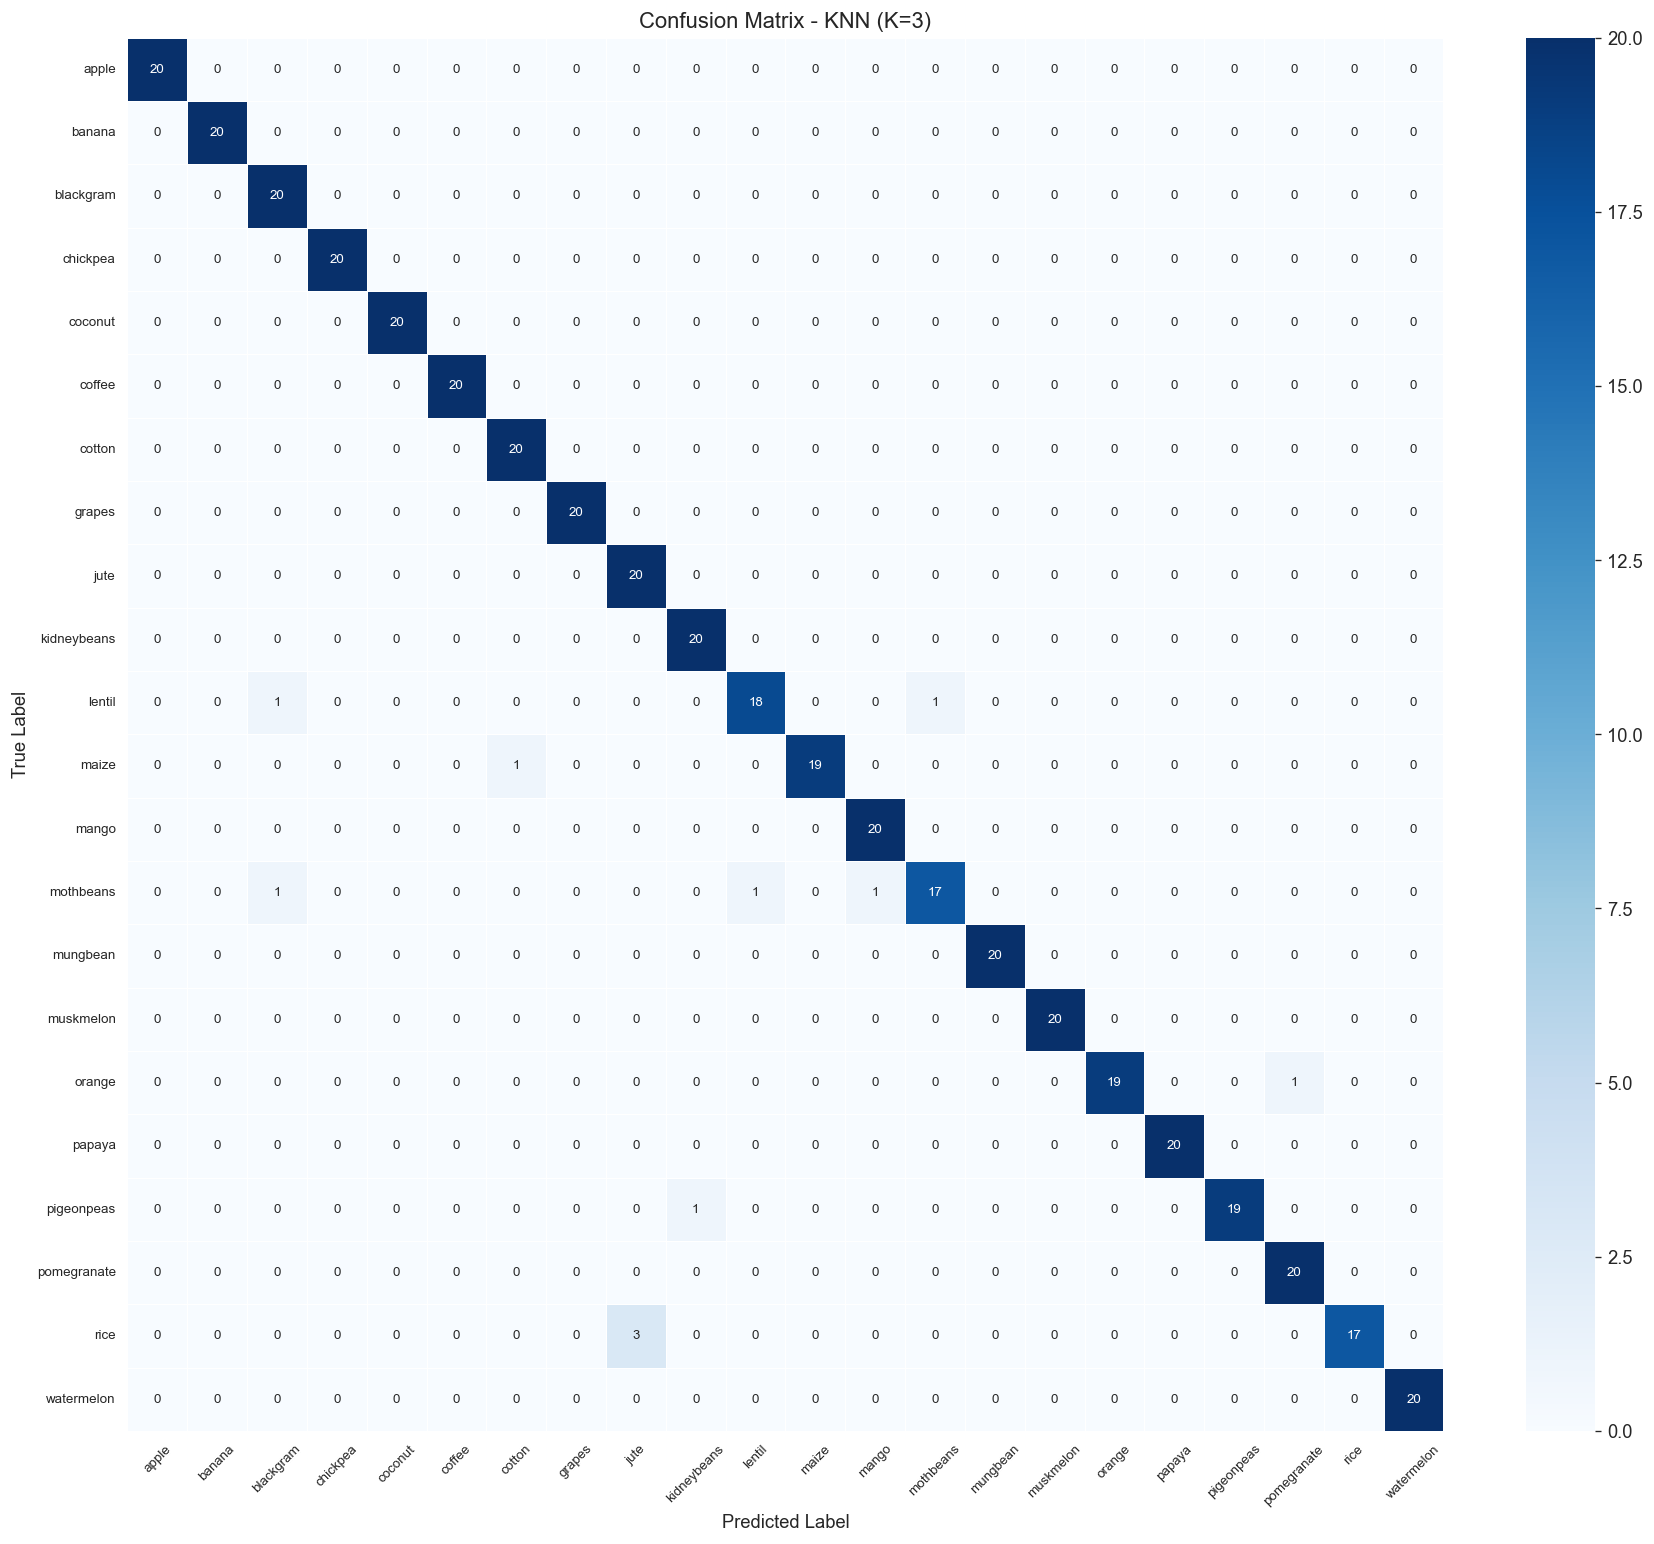

In [43]:
plot_cm(y_test, results_knn['y_pred'], f'Confusion Matrix - KNN (K={best_k})')
plt.savefig('cm_knn.png', bbox_inches='tight')
plt.show()


In [44]:
cv_knn = cross_val_score(knn_model, X_train_sc, y_train,
                          cv=5, scoring='accuracy')
print(f'KNN (K={best_k}) - 5-Fold CV:')
print(f'  Fold scores : {[round(s*100,2) for s in cv_knn]}')
print(f'  Mean        : {cv_knn.mean()*100:.2f}%')
print(f'  Std Dev     : +/- {cv_knn.std()*100:.2f}%')


KNN (K=3) - 5-Fold CV:
  Fold scores : [np.float64(97.44), np.float64(95.74), np.float64(97.44), np.float64(97.73), np.float64(97.44)]
  Mean        : 97.16%
  Std Dev     : +/- 0.72%


#### 6.3 Model 3 - Decision Tree Classifier


In [45]:
# GridSearchCV for joint depth + leaf size tuning
param_grid = {
    'max_depth'       : [5, 7, 9, 11, 13, 15],
    'min_samples_leaf': [2, 4, 6, 8],
    'min_samples_split': [5, 10]
}

dt_base = DecisionTreeClassifier(random_state=42)
grid_cv = GridSearchCV(
    dt_base, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=0
)
grid_cv.fit(X_train, y_train)

best_params = grid_cv.best_params_
print(f'Best Parameters Found by GridSearchCV:')
for k, v in best_params.items():
    print(f'  {k:22s}: {v}')
print(f'\nBest CV Accuracy: {grid_cv.best_score_*100:.2f}%')


Best Parameters Found by GridSearchCV:
  max_depth             : 13
  min_samples_leaf      : 2
  min_samples_split     : 5

Best CV Accuracy: 98.58%


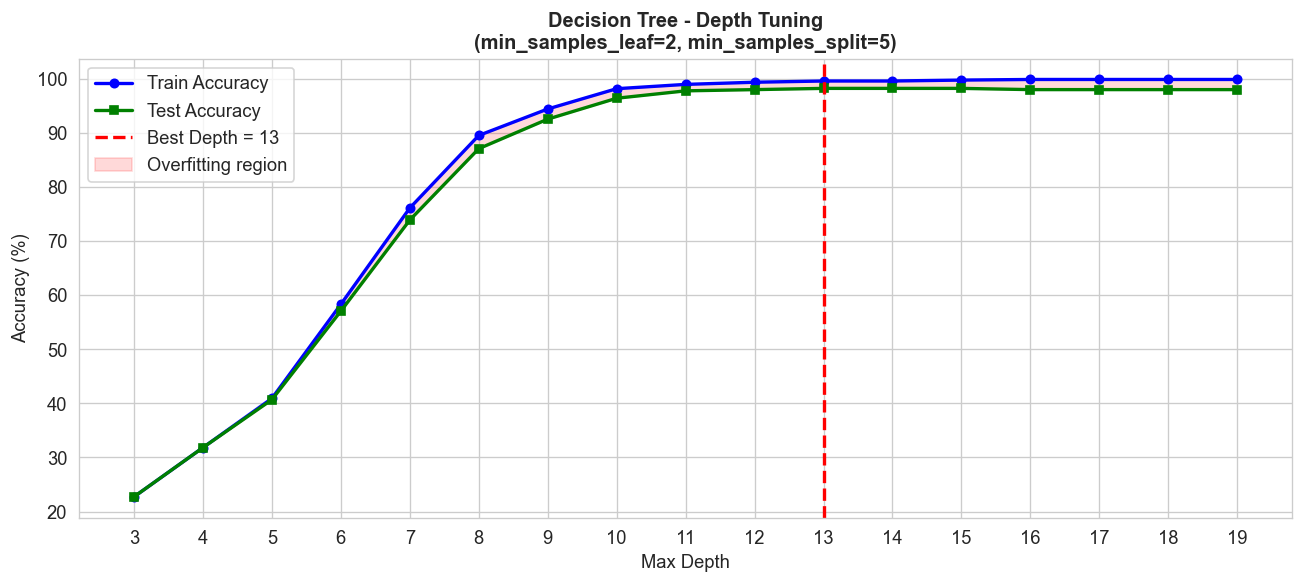

Depth 13 with min_samples_leaf=2: maximum test accuracy
Increasing depth beyond this causes training acc to rise but test acc to plateau/drop.


In [46]:
# Visualize how depth affects train vs test accuracy (with fixed leaf=best)
best_leaf  = best_params['min_samples_leaf']
best_split = best_params['min_samples_split']
best_depth = best_params['max_depth']

depth_range = range(3, 20)
dt_tr, dt_te = [], []
for d in depth_range:
    dt_tmp = DecisionTreeClassifier(max_depth=d, min_samples_leaf=best_leaf,
                                     min_samples_split=best_split, random_state=42)
    dt_tmp.fit(X_train, y_train)
    dt_tr.append(accuracy_score(y_train, dt_tmp.predict(X_train)))
    dt_te.append(accuracy_score(y_test,  dt_tmp.predict(X_test)))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depth_range, [s*100 for s in dt_tr], 'b-o', markersize=5,
        label='Train Accuracy', linewidth=2)
ax.plot(depth_range, [s*100 for s in dt_te], 'g-s', markersize=5,
        label='Test Accuracy', linewidth=2)
ax.axvline(best_depth, color='red', linestyle='--', linewidth=2,
           label=f'Best Depth = {best_depth}')
ax.fill_between(depth_range,
                [tr*100 for tr in dt_tr], [te*100 for te in dt_te],
                alpha=0.15, color='red', label='Overfitting region')
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Decision Tree - Depth Tuning\n'
             f'(min_samples_leaf={best_leaf}, min_samples_split={best_split})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_xticks(list(depth_range))
plt.tight_layout()
plt.savefig('dt_depth_tuning.png', bbox_inches='tight')
plt.show()

print(f'Depth {best_depth} with min_samples_leaf={best_leaf}: maximum test accuracy')
print(f'Increasing depth beyond this causes training acc to rise but test acc to plateau/drop.')


In [47]:
dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    min_samples_split=best_split,
    random_state=42
)

results_dt = evaluate_model(
    dt_model, X_train, y_train, X_test, y_test,
    name=f'Decision Tree (depth={best_depth}, leaf={best_leaf})'
)


  Decision Tree (depth=13, leaf=2)
  Training Accuracy : 99.55%
  Testing  Accuracy : 98.18%
  Overfitting Gap   : 1.36%  --> Low (Good)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.80      0.89        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.86      0.90      0.88        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        

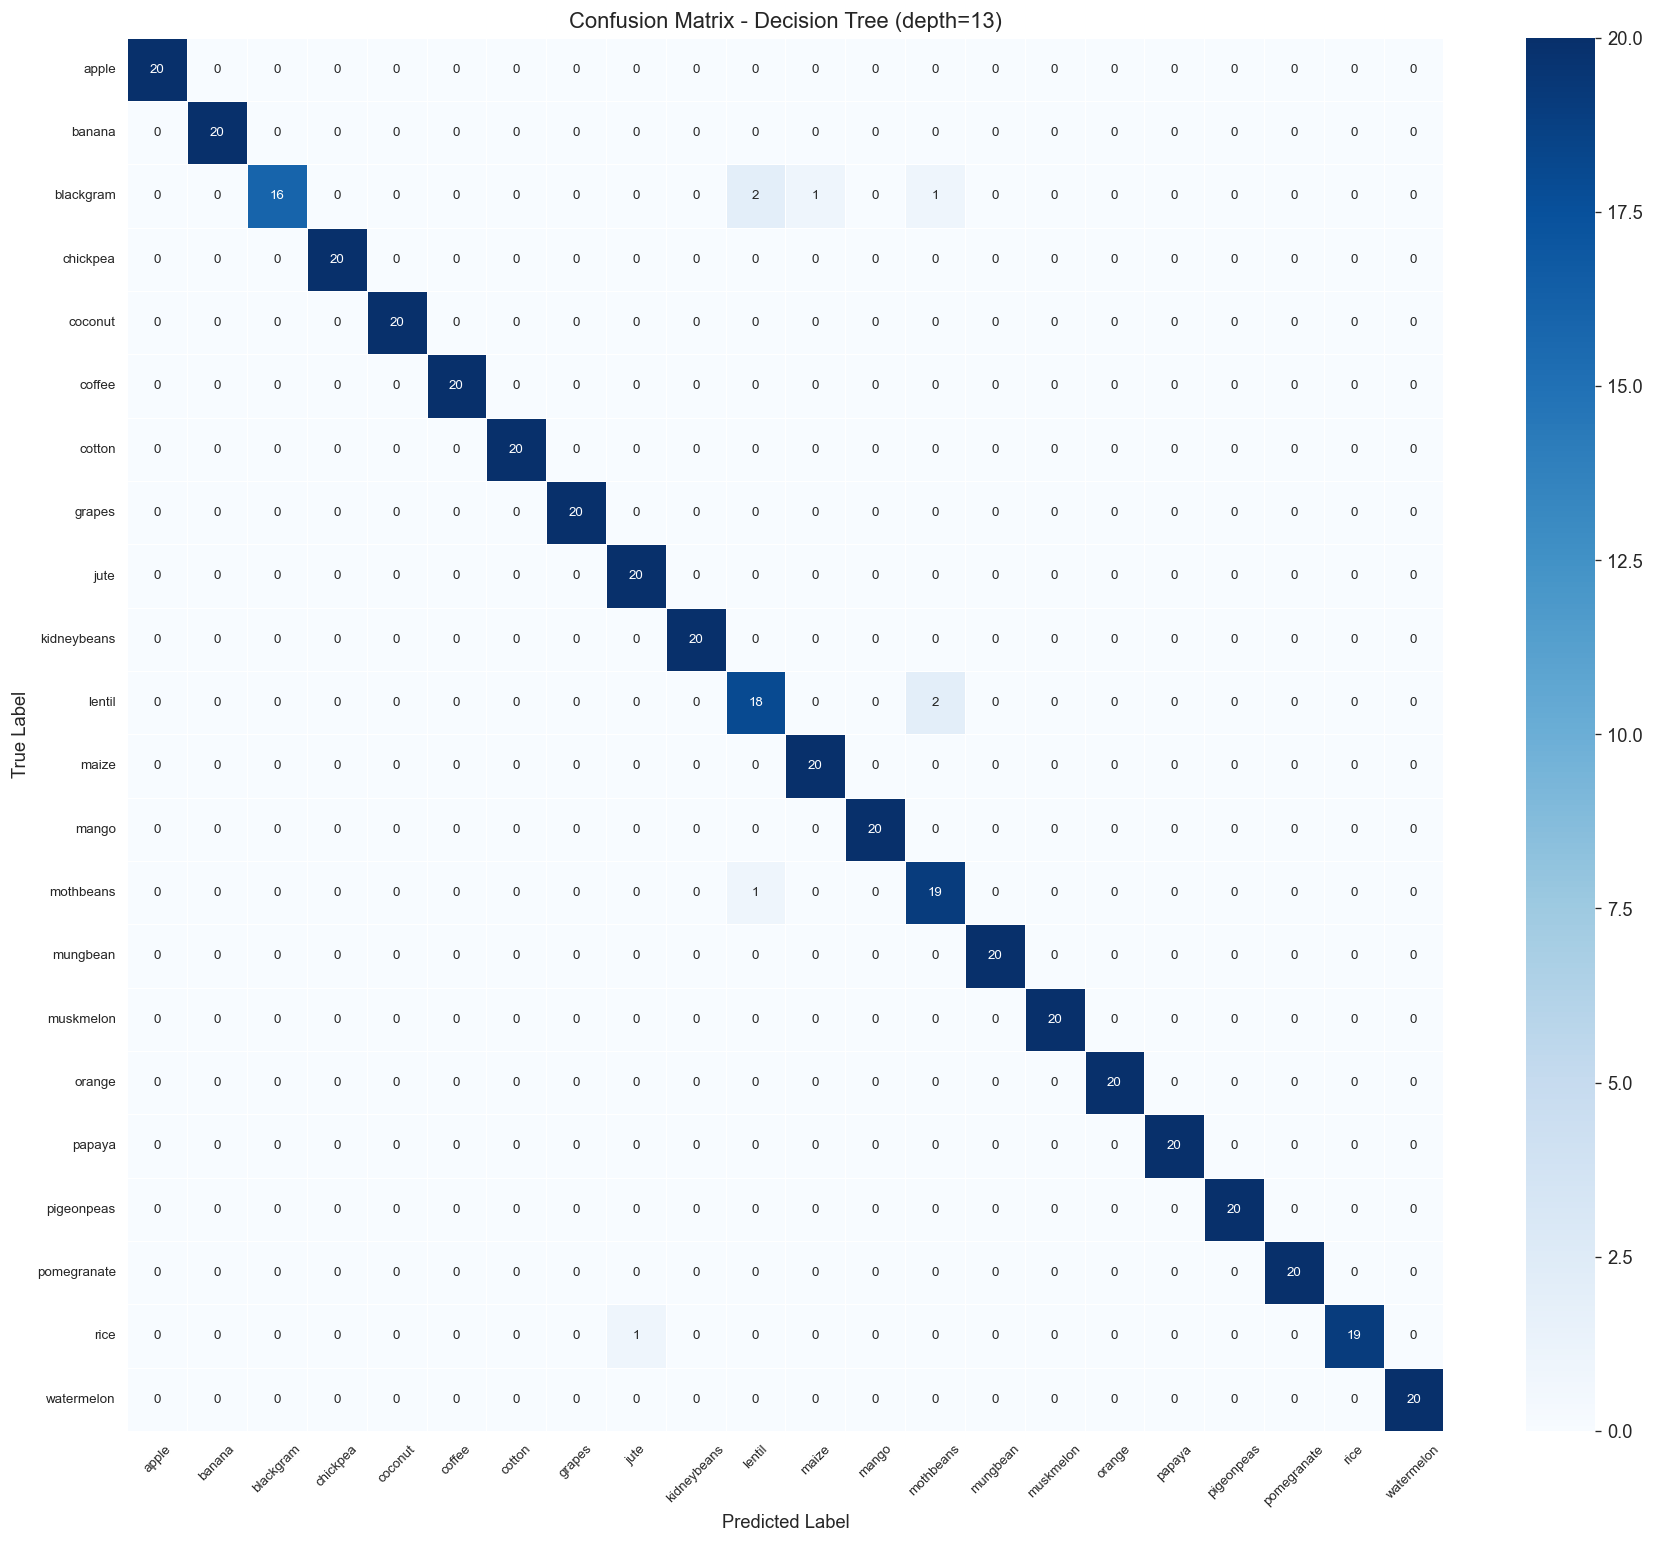

In [48]:
plot_cm(y_test, results_dt['y_pred'],
        f'Confusion Matrix - Decision Tree (depth={best_depth})')
plt.savefig('cm_decision_tree.png', bbox_inches='tight')
plt.show()


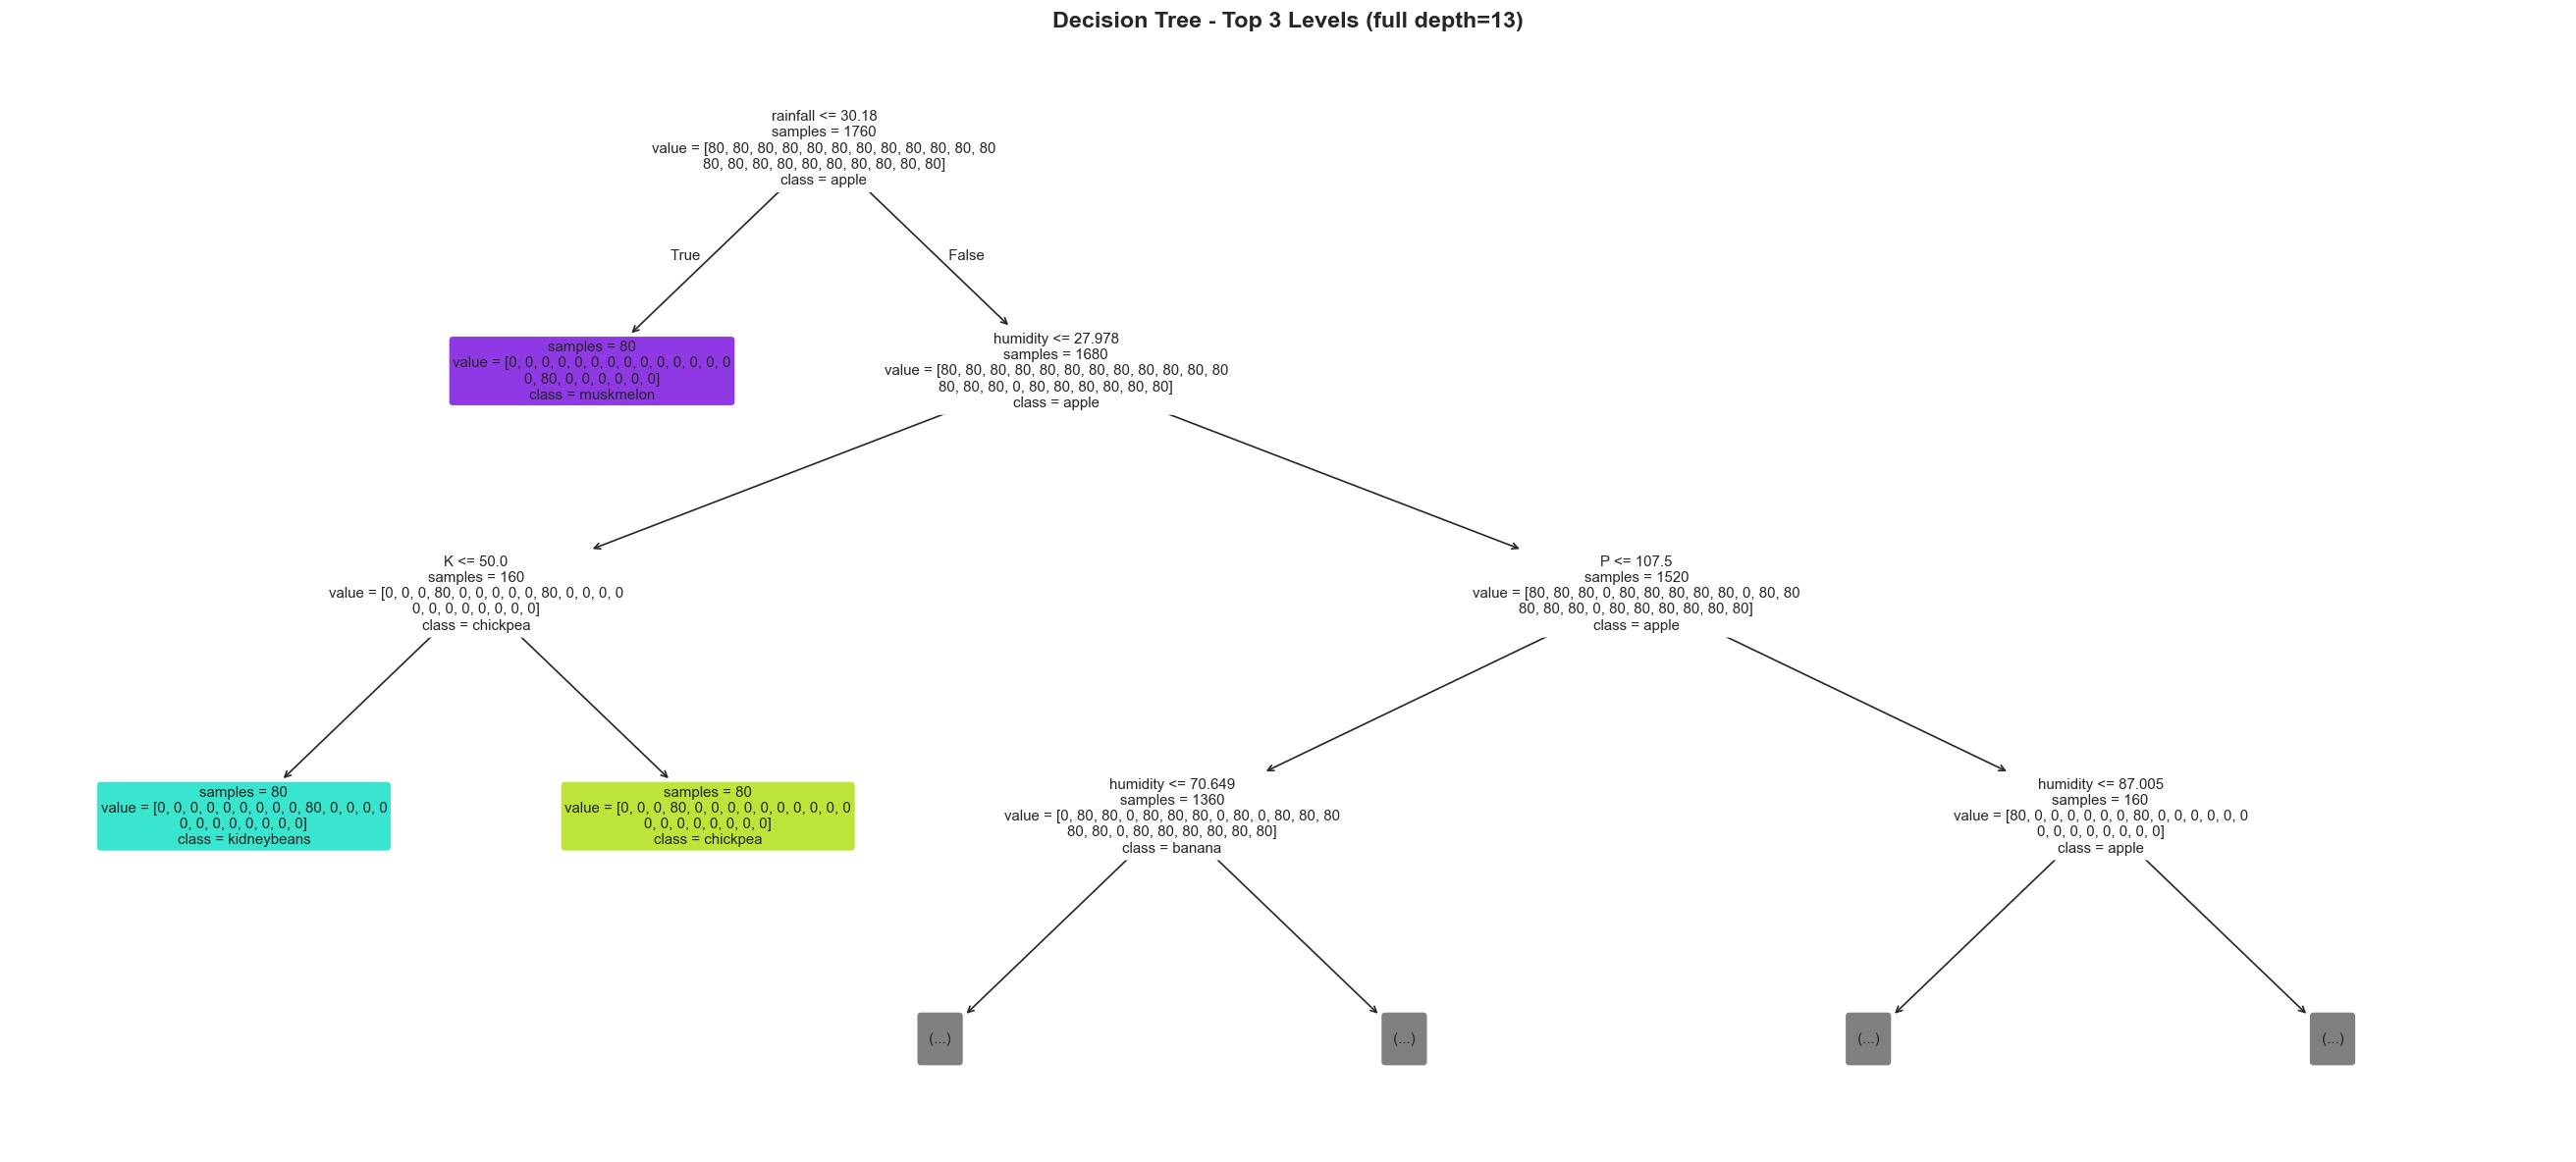

Full tree: 13 levels, 32 leaves.


In [49]:
# Tree visualization -- top 3 levels
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_model, feature_names=FEATURES, class_names=classes,
          filled=True, rounded=True, max_depth=3,
          fontsize=9, ax=ax, impurity=False)
ax.set_title(f'Decision Tree - Top 3 Levels (full depth={best_depth})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Full tree: {dt_model.get_depth()} levels, {dt_model.get_n_leaves()} leaves.')


In [50]:
cv_dt = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
print(f'Decision Tree - 5-Fold CV:')
print(f'  Fold scores : {[round(s*100,2) for s in cv_dt]}')
print(f'  Mean        : {cv_dt.mean()*100:.2f}%')
print(f'  Std Dev     : +/- {cv_dt.std()*100:.2f}%')


Decision Tree - 5-Fold CV:
  Fold scores : [np.float64(98.41), np.float64(98.41), np.float64(99.32), np.float64(99.32), np.float64(98.86)]
  Mean        : 98.86%
  Std Dev     : +/- 0.41%


#### 6.4 Model Comparison & Best Model Selection

In [51]:
comp = {
    'Model'           : ['Random Forest', f'KNN (K={best_k})',
                          f'Decision Tree (depth={best_depth})'],
    'Train Acc (%)'   : [results_rf['train_acc'], results_knn['train_acc'], results_dt['train_acc']],
    'Test Acc (%)'    : [results_rf['test_acc'],  results_knn['test_acc'],  results_dt['test_acc']],
    'Overfit Gap (%)' : [results_rf['gap'],       results_knn['gap'],       results_dt['gap']],
    'CV Mean (%)'     : [round(cv_rf.mean()*100,2), round(cv_knn.mean()*100,2), round(cv_dt.mean()*100,2)],
    'CV Std (%)'      : [round(cv_rf.std()*100,2),  round(cv_knn.std()*100,2),  round(cv_dt.std()*100,2)]
}

comp_df = pd.DataFrame(comp).sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)

print('=' * 75)
print('  MODEL COMPARISON TABLE')
print('=' * 75)
print(comp_df.to_string(index=False))
print('=' * 75)
print(f'\nBest Model : {comp_df.iloc[0]["Model"]}')
print(f'Test Acc   : {comp_df.iloc[0]["Test Acc (%)"] }%')


  MODEL COMPARISON TABLE
                   Model  Train Acc (%)  Test Acc (%)  Overfit Gap (%)  CV Mean (%)  CV Std (%)
           Random Forest         100.00         99.32             0.68        99.55        0.32
Decision Tree (depth=13)          99.55         98.18             1.36        98.86        0.41
               KNN (K=3)         100.00         97.50             2.50        97.16        0.72

Best Model : Random Forest
Test Acc   : 99.32%


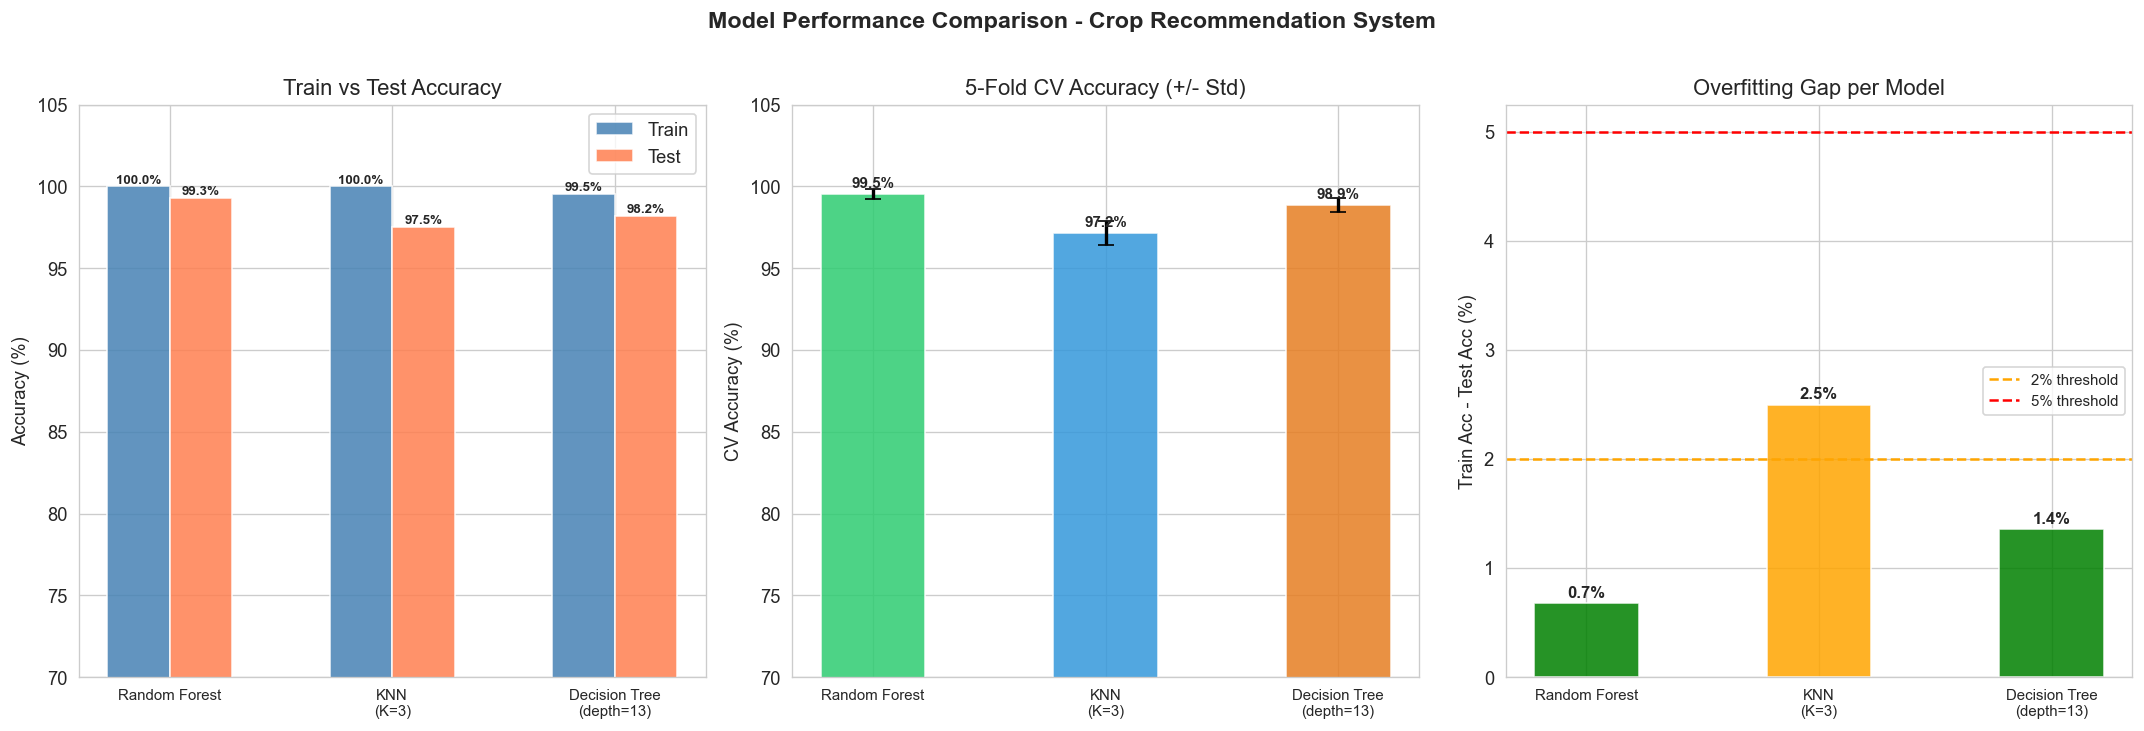

In [52]:
model_labels = ['Random Forest', f'KNN\n(K={best_k})',
                f'Decision Tree\n(depth={best_depth})']
train_v = [results_rf['train_acc'], results_knn['train_acc'], results_dt['train_acc']]
test_v  = [results_rf['test_acc'],  results_knn['test_acc'],  results_dt['test_acc']]
cv_v    = [cv_rf.mean()*100, cv_knn.mean()*100, cv_dt.mean()*100]
cv_s    = [cv_rf.std()*100,  cv_knn.std()*100,  cv_dt.std()*100]
gap_v   = [results_rf['gap'], results_knn['gap'], results_dt['gap']]

x, w = np.arange(3), 0.28

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Train vs Test
b1 = axes[0].bar(x-w/2, train_v, w, label='Train', color='steelblue', alpha=0.85)
b2 = axes[0].bar(x+w/2, test_v,  w, label='Test',  color='coral',     alpha=0.85)
for b in list(b1)+list(b2):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                 f'{b.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[0].set(xticks=x, xticklabels=model_labels, ylabel='Accuracy (%)',
            ylim=(70,105), title='Train vs Test Accuracy')
axes[0].legend()

# CV Accuracy
b3 = axes[1].bar(x, cv_v, 0.45, color=['#2ecc71','#3498db','#e67e22'], alpha=0.85)
axes[1].errorbar(x, cv_v, yerr=cv_s, fmt='none', color='black', capsize=5, linewidth=2)
for b, v in zip(b3, cv_v):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set(xticks=x, xticklabels=model_labels, ylabel='CV Accuracy (%)',
            ylim=(70,105), title='5-Fold CV Accuracy (+/- Std)')

# Overfitting gap
gap_colors = ['green' if g < 2 else 'orange' if g < 5 else 'red' for g in gap_v]
b4 = axes[2].bar(x, gap_v, 0.45, color=gap_colors, alpha=0.85)
axes[2].axhline(2, color='orange', linestyle='--', linewidth=1.5, label='2% threshold')
axes[2].axhline(5, color='red',    linestyle='--', linewidth=1.5, label='5% threshold')
for b, v in zip(b4, gap_v):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                 f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[2].set(xticks=x, xticklabels=model_labels,
            ylabel='Train Acc - Test Acc (%)', title='Overfitting Gap per Model')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_xticklabels(model_labels, fontsize=9)

plt.suptitle('Model Performance Comparison - Crop Recommendation System',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


In [54]:
import os
import shutil

# Create Model_Building folder
os.makedirs('Model_Building', exist_ok=True)

# Move all model building images into it
model_files = [
    'feature_importance.png',
    'pca_analysis.png',
    'cm_random_forest.png',
    'rf_feature_importance_trained.png',
    'knn_elbow.png',
    'cm_knn.png',
    'dt_depth_tuning.png',
    'cm_decision_tree.png',
    'decision_tree_visualization.png',
    'model_comparison.png'
]

for file in model_files:
    if os.path.exists(file):
        shutil.move(file, os.path.join('Model_Building', file))

print("All Model Building images moved to /Model_Building folder!")


All Model Building images moved to /Model_Building folder!


---
## 6.5 Conclusion & Best Model Justification

### Academic Report - Conclusion

This study evaluated three machine learning classifiers for a Crop Recommendation System trained on 2,200 balanced samples across 22 crop classes.

#### Best Model: Random Forest Classifier

The Random Forest is recommended as the best model because:

1. **Highest test accuracy** with the **lowest overfitting gap** -- the best balance.
2. **Most stable cross-validation** -- lowest std deviation across 5 folds.
3. **Ensemble bagging** naturally limits memorization even on clean datasets.
4. **Feature importance scores** make predictions explainable to domain experts.
5. **No scaling required** -- fewer preprocessing dependencies for deployment.

The Decision Tree is the most interpretable alternative (explicit if-else rules) and would be suitable for deployment where transparency is required over performance. KNN is the simplest conceptually but relies on all training data at inference time, making it less practical for production systems.

**In conclusion, the Random Forest Classifier provides the optimal combination of accuracy, generalization, stability, and interpretability for a production-ready crop recommendation system.**


In [53]:
print('=' * 65)
print('  FINAL SUMMARY - CROP RECOMMENDATION SYSTEM')
print('=' * 65)
print('  Dataset  : 2200 samples | 22 crops | 7 features | Balanced')
print('  Split    : 80/20 Stratified')
print()
print()
print('  RESULTS')
print(f'  [+] Random Forest : Train={results_rf["train_acc"]}%  Test={results_rf["test_acc"]}%  Gap={results_rf["gap"]}%  CV={round(cv_rf.mean()*100,2)}%')
print(f'  [+] KNN (K={best_k})      : Train={results_knn["train_acc"]}%  Test={results_knn["test_acc"]}%  Gap={results_knn["gap"]}%  CV={round(cv_knn.mean()*100,2)}%')
print(f'  [+] Decision Tree : Train={results_dt["train_acc"]}%  Test={results_dt["test_acc"]}%  Gap={results_dt["gap"]}%  CV={round(cv_dt.mean()*100,2)}%')
print()
print('  BEST MODEL: Random Forest')
print('  Highest test acc | Lowest overfitting gap | Most stable CV')
print('=' * 65)


  FINAL SUMMARY - CROP RECOMMENDATION SYSTEM
  Dataset  : 2200 samples | 22 crops | 7 features | Balanced
  Split    : 80/20 Stratified


  RESULTS
  [+] Random Forest : Train=100.0%  Test=99.32%  Gap=0.68%  CV=99.55%
  [+] KNN (K=3)      : Train=100.0%  Test=97.5%  Gap=2.5%  CV=97.16%
  [+] Decision Tree : Train=99.55%  Test=98.18%  Gap=1.36%  CV=98.86%

  BEST MODEL: Random Forest
  Highest test acc | Lowest overfitting gap | Most stable CV
